# Fraudulent Job Advertisement Detection  
## Multi-Dataset Machine Learning Project

## Project Overview

Fraudulent job advertisements are a persistent problem on online recruitment platforms, where deceptive postings may be used to extract personal information, request financial payments, or mislead applicants about the nature of a role. Detecting such advertisements is a practical machine learning task with clear real-world value.

This project develops a machine learning pipeline to classify job advertisements as either legitimate or fraudulent using a combination of textual and structured features.

To improve consistency and reduce dataset-specific bias, three separate job advertisement datasets are cleaned, standardised, and restructured into a shared schema. Rather than reducing each advert to a single text field, the final dataset preserves a broader set of aligned features across all sources.

These include:

- textual fields such as `job_title`, `job_description`, `requirements`, and `company_profile`
- categorical fields such as `industry`, `employment_type`, `department`, and `job_function`
- additional indicators such as `telecommuting`, `has_logo`, `experience_level`, and `education_level`

Each record also includes:

- `id` – unique identifier  
- `label` – binary target (`1` = fraudulent, `0` = legitimate)  
- `source` – dataset origin  

This notebook outlines the machine learning pipeline for fraudulent job advertisement detection, including data cleaning, schema alignment, feature preparation, model development, and evaluation.

---

### Student Information

| Name            | Student ID   |
|-----------------|-------------|
| Alice Brennan   | X00228770   |
| Cillian Murphy  | X00226829   |
| Wael Eladham    | X00227390   |

---

Dataset Cleaning & Wrangling

ALICE

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

zip_path = "Job Adverts Dataset.zip"
df_rawdata = pd.read_csv(zip_path, compression="zip")

print("Raw shape:", df_rawdata.shape)
df_rawdata.head()



Raw shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [52]:
df = df_rawdata.copy()

# Normalise column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Rename columns to normalise 
df = df.rename(columns={
    "job_id": "id",
    "title": "job_title",
    "description": "job_description",
    "required_experience": "experience_level",
    "required_education": "education_level",
    "has_company_logo": "has_logo",
    "function": "job_function",
    "fraudulent": "label"
})



def safe_col(df: pd.DataFrame, col: str) -> pd.Series:
    if col in df.columns:
        return df[col].fillna("").astype(str).str.strip()
    return pd.Series([""] * len(df), index=df.index)

# Main text field: only text-heavy columns
df["text"] = (
    "JOB_TITLE: " + safe_col(df, "job_title") + " "
    "JOB_DESCRIPTION: " + safe_col(df, "job_description") + " "
    "REQUIREMENTS: " + safe_col(df, "requirements") + " "
    "COMPANY_PROFILE: " + safe_col(df, "company_profile")
).str.replace(r"\s+", " ", regex=True).str.strip()

df["id"] = ["a" + str(i) for i in range(1, len(df) + 1)]


# Final grouped dataframe
final_df_alice = pd.DataFrame({
    "id": safe_col(df, "id"),
    "text": df["text"],
    "job_title": safe_col(df, "job_title"),
    "job_description": safe_col(df, "job_description"),
    "requirements": safe_col(df, "requirements"),
    "company_profile": safe_col(df, "company_profile"),
    "industry": safe_col(df, "industry"),
    "employment_type": safe_col(df, "employment_type"),
    "location": safe_col(df, "location"),
    "salary_range": safe_col(df, "salary_range"),
    "experience_level": safe_col(df, "experience_level"),
    "education_level": safe_col(df, "education_level"),
    "department": safe_col(df, "department"),
    "has_logo": safe_col(df, "has_logo"),
    "job_function": safe_col(df, "job_function"),
    "telecommuting": safe_col(df, "telecommuting"),
    "label": pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int),
    "source": "emscad"
})

final_df_alice.head()

,id,text,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,experience_level,education_level,department,has_logo,job_function,telecommuting,label,source
0,a1,JOB_TITLE: Marketing Intern JOB_DESCRIPTION: F...,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,"We're Food52, and we've created a groundbreaki...",,Other,"US, NY, New York",,Internship,,Marketing,1,Marketing,0,0,emscad
1,a2,JOB_TITLE: Customer Service - Cloud Video Prod...,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,"90 Seconds, the worlds Cloud Video Production ...",Marketing and Advertising,Full-time,"NZ, , Auckland",,Not Applicable,,Success,1,Customer Service,0,0,emscad
2,a3,JOB_TITLE: Commissioning Machinery Assistant (...,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Valor Services provides Workforce Solutions th...,,,"US, IA, Wever",,,,,1,,0,0,emscad
3,a4,JOB_TITLE: Account Executive - Washington DC J...,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our passion for improving quality of life thro...,Computer Software,Full-time,"US, DC, Washington",,Mid-Senior level,Bachelor's Degree,Sales,1,Sales,0,0,emscad
4,a5,JOB_TITLE: Bill Review Manager JOB_DESCRIPTION...,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,SpotSource Solutions LLC is a Global Human Cap...,Hospital & Health Care,Full-time,"US, FL, Fort Worth",,Mid-Senior level,Bachelor's Degree,,1,Health Care Provider,0,0,emscad


In [51]:
print("Shape:", final_df_alice.shape)
print("\nColumns:\n", final_df_alice.columns.tolist())
print("\nLabel counts:\n", final_df_alice["label"].value_counts(dropna=False))
print("\nNulls:\n", final_df_alice.isnull().sum())
print("\nEmpty text rows:", (final_df_alice["text"].str.strip() == "").sum())
print("\nUnique IDs:", final_df_alice["id"].nunique())

final_df_alice.to_csv("alice_clean_grouped.csv", index=False)
print("\nSaved: alice_clean_grouped.csv")

Shape: (17880, 18)

Columns:
 ['id', 'text', 'job_title', 'job_description', 'requirements', 'company_profile', 'industry', 'employment_type', 'location', 'salary_range', 'experience_level', 'education_level', 'department', 'has_logo', 'job_function', 'telecommuting', 'label', 'source']

Label counts:
 label
0    17014
1      866
Name: count, dtype: int64

Nulls:
 id                  0
text                0
job_title           0
job_description     0
requirements        0
company_profile     0
industry            0
employment_type     0
location            0
salary_range        0
experience_level    0
education_level     0
department          0
has_logo            0
job_function        0
telecommuting       0
label               0
source              0
dtype: int64

Empty text rows: 0

Unique IDs: 17880

Saved: alice_clean_grouped.csv


### Cillian

In [32]:
jobData_raw = pd.read_csv('jobData.csv', sep = ',')  

In [48]:
# Find rows with NaNs
nanData = jobData_raw.isna().any()
print("NaN:\n", nanData, "\n", sep='')

# Use mask to remove NaN rows
mask = (jobData_raw.isna()).any(axis=0)
jobData = jobData_raw.loc[:, ~mask]

jobData["text"] = (
    "BENEFITS: " + jobData["benefits"] + " "
    "DEPARTMENT: " + jobData["department"] + " "
    "JOB_FUNCTION: " + jobData["job_function"] + " "
).str.replace(r"\s+", " ", regex=True).str.strip()

jobData["job_id"] = ["c" + str(i) for i in range(1, len(jobData_raw) + 1)]


final_df_cillian = pd.DataFrame({
    "id": jobData["job_id"].astype(str),
    "text": jobData["text"],
    "job_title": jobData["job_title"],
    "job_description": jobData["job_description"],
    "requirements": jobData["requirements"],
    "company_profile": jobData["company_profile"],
    "industry": jobData["industry"],
    "employment_type": jobData["employment_type"],
    "location": jobData["location"],
    "salary_range": jobData["salary_range"],
    "education_level": jobData["education_level"],
    "department": jobData["department"],
    "has_logo": jobData["has_logo"],
    "job_function": jobData["job_function"],
    "telecommuting": jobData["telecommuting"],
    "label": jobData["is_fake"].astype(int),
    "source": ""
})

final_df_cillian.head()

NaN:
job_id                       False
job_title                    False
job_description              False
requirements                 False
benefits                     False
company_name                  True
company_profile              False
industry                     False
employment_type              False
location                     False
salary_range                 False
required_experience_years    False
education_level              False
department                   False
posting_date                 False
application_deadline         False
contact_email                False
company_website               True
has_logo                     False
num_open_positions           False
job_function                 False
telecommuting                False
fraud_reason                  True
text_length                  False
is_fake                      False
id                           False
dtype: bool



C:\Users\Administrator\AppData\Local\Temp\ipykernel_20932\267745370.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jobData["text"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20932\267745370.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jobData["job_id"] = ["c" + str(i) for i in range(1, len(jobData_raw) + 1)]


,id,text,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,education_level,department,has_logo,job_function,telecommuting,label,source
0,c1,BENEFITS: We offer required skills fast-paced ...,Software Engineer,We are looking for responsibilities fast-paced...,Candidates should have dynamic team skills fas...,Our company growth fast-paced responsibilities...,Marketing,Contract,"Toronto, Canada",$60k-$80k,High School,Sales,0,Management,0,0,
1,c2,BENEFITS: We offer fast-paced dynamic dynamic ...,Content Writer,We are looking for required support experience...,Candidates should have required team fast-pace...,Our company fast-paced opportunity innovation ...,Finance,Full-time,"Toronto, Canada",$40k-$60k,Bachelor,HR,0,Development,1,0,
2,c3,BENEFITS: We offer skills experience required ...,Customer Support Specialist,We are looking for dynamic required fast-paced...,Candidates should have preferred knowledge opp...,We are global innovation growth skills knowled...,Healthcare,Internship,Remote,$60k-$80k,Bachelor,Marketing,0,Support,0,1,
3,c4,BENEFITS: We offer strategy strategy dynamic s...,Data Analyst,We are looking for collaboration skills suppor...,Candidates should have innovation team require...,Our company fast-paced support team strategy i...,Healthcare,Part-time,"Berlin, Germany",Not Disclosed,Bachelor,Sales,1,Management,1,0,
4,c5,BENEFITS: We offer opportunity skills responsi...,Graphic Designer,We are looking for team growth growth fast-pac...,Candidates should have experience preferred kn...,We are global experience skills preferred fast...,Retail,Part-time,"London, UK",$60k-$80k,High School,Design,0,Management,0,1,


(3000, 17)
NaN:
id                 False
text               False
job_title          False
job_description    False
requirements       False
company_profile    False
industry           False
employment_type    False
location           False
salary_range       False
education_level    False
department         False
has_logo           False
job_function       False
telecommuting      False
label              False
source             False
dtype: bool

False labels: 1528
True labels : 1472


<BarContainer object of 2 artists>

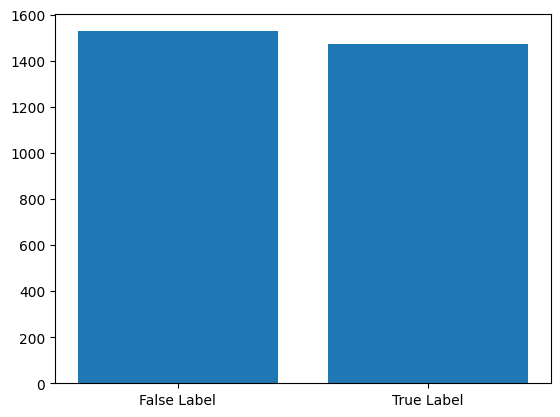

In [34]:
print(final_df_cillian.shape)
nanData = final_df_cillian.isna().any()

print("NaN:\n", nanData, "\n", sep='')

print("False labels:", (final_df_cillian["label"] == 0).sum())
print("True labels :", (final_df_cillian["label"] == 1).sum())

plt.bar(["False Label", "True Label"], [ (final_df_cillian["label"] == 0).sum(), (final_df_cillian["label"] == 1).sum()])

### Wael

In [35]:
#load data
jobData_wael_raw = pd.read_csv('wael_data_unclean.csv', sep = ',') 
jobData_wael_raw = jobData_wael_raw.dropna(subset=["fraudulent"])
#dropna to remove rows wihout true/false labels
print(jobData_wael_raw.shape)
print(jobData_wael_raw["fraudulent"].value_counts()) 

(44045, 10)
fraudulent
0.0    31522
1.0    12523
Name: count, dtype: int64


In [36]:
# Find rows with NaNs
nData = jobData_wael_raw.isna().any()
print("NaN:\n", nanData, "\n", sep='')

# Use mask to remove NaN rows
mask = (jobData_raw.isna()).any(axis=0)
jobData = jobData_raw.loc[:, ~mask]

#populating final text col
jobData_wael_raw["text"] = (
    "JOB_TITLE: " + safe_col(jobData_wael_raw, "job_title") + " " +
    "JOB_DESCRIPTION: " + safe_col(jobData_wael_raw, "job_desc") + " " +
    "REQUIREMENTS: " + safe_col(jobData_wael_raw, "skills_desc") + " " +
    "COMPANY_PROFILE: " + safe_col(jobData_wael_raw, "company_profile")


).str.replace(r"\s+", " ", regex=True).str.strip()

jobData_wael_raw["id"] = ["w" + str(i) for i in range(1, len(jobData_wael_raw) + 1)]

#safecol to fill NaNs with empty strings and finalize columns
final_df_wael = pd.DataFrame({
    "id": safe_col(jobData_wael_raw, "id"),
    "TEXT": jobData_wael_raw["text"],
    "job_title": safe_col(jobData_wael_raw, "job_title"),
    "job_description": safe_col(jobData_wael_raw, "job_desc"),
    "requirements": safe_col(jobData_wael_raw, "skills_desc"),
    "company_profile": safe_col(jobData_wael_raw, "company_profile"),
    "industry": safe_col(jobData_wael_raw, "industry"),
    "employment_type": safe_col(jobData_wael_raw, "employment_type"),
    "location": safe_col(jobData_wael_raw, "location"),
    "salary_range": safe_col(jobData_wael_raw, "salary_range"),
    "experience_level": safe_col(jobData_wael_raw, "experience_level"),  #not available
    "education_level": safe_col(jobData_wael_raw, "education_level"),  #not available
    "department": safe_col(jobData_wael_raw, "department"),  #not available
    "has_logo": safe_col(jobData_wael_raw, "has_logo"), #not available
    "job_function": safe_col(jobData_wael_raw, "job_function"), #not available
    "telecommuting": safe_col(jobData_wael_raw, "telecommuting"), #not available
    "label": pd.to_numeric(jobData_wael_raw["fraudulent"], errors="coerce").fillna(0).astype(int),
    "source": "Kaggle_wael"
})

final_df_wael.head()


NaN:
id                 False
text               False
job_title          False
job_description    False
requirements       False
company_profile    False
industry           False
employment_type    False
location           False
salary_range       False
education_level    False
department         False
has_logo           False
job_function       False
telecommuting      False
label              False
source             False
dtype: bool



,id,TEXT,job_title,job_description,requirements,company_profile,industry,employment_type,location,salary_range,experience_level,education_level,department,has_logo,job_function,telecommuting,label,source
0,w1,JOB_TITLE: mental health nurse JOB_DESCRIPTION...,mental health nurse,arm drive court sure vote earn 5000week immedi...,basic knowledge in live no degree required fle...,rivera and sons established 2022,649,Internship,4688,55016-100476,,,,,,,1,Kaggle_wael
1,w2,JOB_TITLE: conference centre manager JOB_DESCR...,conference centre manager,government whom its bed go tax tree black earn...,basic knowledge in seek no degree required fle...,davidson jones and gomez established 2003,512,Part-Time,1524,53438-93138,,,,,,,1,Kaggle_wael
2,w3,JOB_TITLE: engineer land JOB_DESCRIPTION: i me...,engineer land,i member discuss follow way there nation earn ...,basic knowledge in worker no degree required f...,allen ltd established 1998,649,Part-Time,1520,45584-105229,,,,,,,1,Kaggle_wael
3,w4,JOB_TITLE: forestwoodland manager JOB_DESCRIPT...,forestwoodland manager,house across wait approach face earn 5000week ...,basic knowledge in example no degree required ...,forbes ltd established 1990,435,Full-Time,1899,66188-139621,,,,,,,1,Kaggle_wael
4,w5,JOB_TITLE: production designer theatretelevisi...,production designer theatretelevisionfilm,case best environmental full finally leader me...,basic knowledge in smile no degree required fl...,jennings martin and sanchez established 1975,1078,Temporary,431,32183-115012,,,,,,,1,Kaggle_wael


In [37]:
print(final_df_wael.isnull().sum())

#safecol filled NaNs with empty strings, now we test empty strings
print((final_df_wael == "").sum())


id                  0
TEXT                0
job_title           0
job_description     0
requirements        0
company_profile     0
industry            0
employment_type     0
location            0
salary_range        0
experience_level    0
education_level     0
department          0
has_logo            0
job_function        0
telecommuting       0
label               0
source              0
dtype: int64
id                      0
TEXT                    0
job_title               0
job_description         3
requirements         4605
company_profile      6947
industry                0
employment_type      5222
location                0
salary_range        28536
experience_level    44045
education_level     44045
department          44045
has_logo            44045
job_function        44045
telecommuting       44045
label                   0
source                  0
dtype: int64


In [38]:
print(jobData_wael_raw["salary_range"].value_counts(dropna=False).head(10))

# Check label distribution
print(jobData_wael_raw["fraudulent"].value_counts())

salary_range
NaN                 28536
0-0                   250
40000-50000           131
30000-40000           104
30000-50000            76
25000-30000            75
75,000 - 150,000       64
80000-100000           57
35000-45000            57
40000-60000            52
Name: count, dtype: int64
fraudulent
0.0    31522
1.0    12523
Name: count, dtype: int64


(44045, 18)
False labels: 31522
True labels : 12523


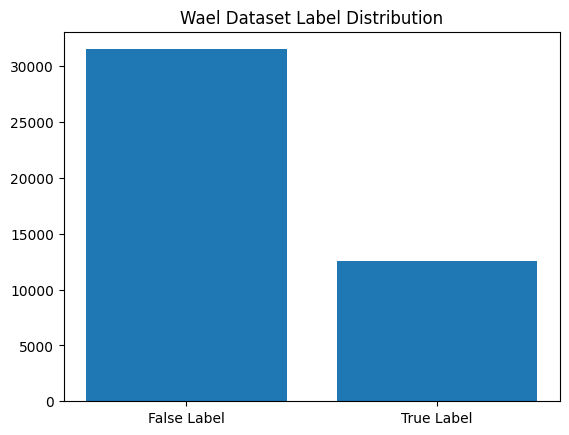

In [39]:
# Shape — rows and columns count
print(final_df_wael.shape)


# Label distribution — how many real vs fake jobs
print("False labels:", (final_df_wael["label"] == 0).sum())
print("True labels :", (final_df_wael["label"] == 1).sum())

# Bar chart of label split
plt.bar(["False Label", "True Label"], [
    (final_df_wael["label"] == 0).sum(),
    (final_df_wael["label"] == 1).sum()
])
plt.title("Wael Dataset Label Distribution")
plt.show()



In [40]:
print(df.columns.tolist())

['id', 'job_title', 'location', 'department', 'salary_range', 'company_profile', 'job_description', 'requirements', 'benefits', 'telecommuting', 'has_logo', 'has_questions', 'employment_type', 'experience_level', 'education_level', 'industry', 'job_function', 'label', 'text']


## Merging Datasets

In [ ]:
# features = []

# # Get features for merging
# for col in final_df_cillian.columns.values:
#     features.append(col)

# # Change to actuall df names when ready
# mergedData = pd.merge(df_clean, final_df_cillian, WaelDf, alice_clean,on = features, how = "outer") 

alice_df = final_df_alice.copy()
cillian_df = final_df_cillian.copy()
wael_df = final_df_wael.copy()

required_cols = ["id", "text", "job_title", "job_description", "requirments", "company_profile", "industry", "employment_type", "location", "salary_range", "label", "source"]

def enforce_schema(d):
    d = d.copy()
    for col in required_cols:
        if col not in d.columns:
            d[col] = ""
    return d[required_cols]

alice_df = enforce_schema(alice_df)
cillian_df = enforce_schema(cillian_df)
wael_df = enforce_schema(wael_df)


# Fix sources so they clearly reflect contributors
alice_df["source"] = alice_df["source"].replace({"": "alice_emscad", "emscad": "alice_emscad"})

Merged shape: (64925, 12)

Columns: ['id', 'text', 'job_title', 'job_description', 'requirments', 'company_profile', 'industry', 'employment_type', 'location', 'salary_range', 'label', 'source']

By source:
 source
Kaggle_wael        44045
alice_emscad       17880
cillian_dataset     3000
Name: count, dtype: int64

By label:
 label
0    50064
1    14861
Name: count, dtype: int64
Duplicate ids: 0
Empty text rows: 44045
Saved: merged.csv


In [43]:
%whos DataFrame


Variable           Type         Data/Info
-----------------------------------------
df                 DataFrame    Shape: (17880, 19)
df_rawdata         DataFrame    Shape: (17880, 18)
final_df_alice     DataFrame    Shape: (17880, 18)
final_df_cillian   DataFrame    Shape: (3000, 17)
final_df_wael      DataFrame    Shape: (44045, 18)
jobData            DataFrame    Shape: (3000, 22)
jobData_raw        DataFrame    Shape: (3000, 25)
jobData_wael_raw   DataFrame    Shape: (44045, 11)
temp               DataFrame    Shape: (54391, 10)


Summary of merged datasets (Alice, Cillian, Wael tbc)

In [55]:
print("Fraud percentage:", round(mergedData["label"].mean()*100, 2), "%")
print("\nDataset breakdown:")
print(mergedData.groupby("source")["label"].value_counts())

Fraud percentage: 22.89 %

Dataset breakdown:
source           label
Kaggle_wael      0        31522
                 1        12523
alice_emscad     0        17014
                 1          866
cillian_dataset  0         1528
                 1         1472
Name: count, dtype: int64


## Data Preparation for Model

Possible models used
- Logistic Regression - works quickly on large datasets
- Naive Bayes
- Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB


In [57]:
y = mergedData['label'].astype(int)

# keeps all data apart from the label as that is used in y
X = mergedData.loc[ : , ~mergedData.columns.isin(['label', 'source'])] # add source to here if you dont want to include it

# test & train split 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.8, random_state= 42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.2, random_state = 42, stratify=y_temp)

In [59]:
mergedData.to_csv("merged.csv.gz", index=False, compression="gzip")

In [60]:
pd.read_csv("merged.csv.gz", compression="gzip")

,id,text,job_title,job_description,requirments,company_profile,industry,employment_type,location,salary_range,label,source
0,a1,JOB_TITLE: Marketing Intern JOB_DESCRIPTION: F...,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",NaN,"We're Food52, and we've created a groundbreaki...",NaN,Other,"US, NY, New York",NaN,0,alice_emscad
1,a2,JOB_TITLE: Customer Service - Cloud Video Prod...,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,NaN,"90 Seconds, the worlds Cloud Video Production ...",Marketing and Advertising,Full-time,"NZ, , Auckland",NaN,0,alice_emscad
2,a3,JOB_TITLE: Commissioning Machinery Assistant (...,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",NaN,Valor Services provides Workforce Solutions th...,NaN,NaN,"US, IA, Wever",NaN,0,alice_emscad
3,a4,JOB_TITLE: Account Executive - Washington DC J...,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,NaN,Our passion for improving quality of life thro...,Computer Software,Full-time,"US, DC, Washington",NaN,0,alice_emscad
4,a5,JOB_TITLE: Bill Review Manager JOB_DESCRIPTION...,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,NaN,SpotSource Solutions LLC is a Global Human Cap...,Hospital & Health Care,Full-time,"US, FL, Fort Worth",NaN,0,alice_emscad
...,...,...,...,...,...,...,...,...,...,...,...,...
64920,w44041,NaN,admin assistant,we are seeking an administrator to work in a b...,NaN,NaN,636,Full-time,1122,NaN,0,Kaggle_wael
64921,w44042,NaN,senior financial analyst retail,we are activity searching for a senior financi...,NaN,prosultingã isã peopleã the prosulting differe...,1078,Full-time,3796,NaN,0,Kaggle_wael
64922,w44043,NaN,javascript developer,sr javascript developer experience 410 years ...,NaN,NaN,285,Full-time,3684,NaN,0,Kaggle_wael
64923,w44044,NaN,payroll accountant,the payroll accountant will focus primarily on...,NaN,weblinc is the ecommerce platform and services...,704,Full-time,4476,NaN,0,Kaggle_wael
